## Extra Project Clash Royale Emote Detection

To train my facial expressions and hand gestures and landmarks I had to manually track:
- Left Hand Gesture (lhg) ✅
- Right Hand Gesture (rhg) ✅
- The 52 facial bendshapes  ✅
- The 20 left finger landmarks * 2  ✅
- The 20 right finger landmarks * 2  ✅

135 Landmarks total landmarks, proudly I made a script which captures and process such landmarks, achieving the impressive mark of +7300 data registers which are map to the following clash royale emotes:
1. "Thumbs_Up_Goblin",
2. "Yawning_Princess",
3. "Goblin_Peace_Sign",
4. "Angry_Barb",
5. "Magician_Fire",
6. "Surprised_Bandit"
7. "Nose_Picking_Barb",
8. "Hog_Ridder_Kiss",
9. "Angry_Giant",
10. "Happy_Royale_Ghost",

And I already know I may be overengineering a problem for just 6 emotes but I want a scalable way to justify the 130 landmarks registered

### Setting Up the notebook

In [45]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv('./processed_emotes.csv')
df.head()

,lhg,rhg,browDownLeft,browDownRight,browInnerUp,browOuterUpLeft,browOuterUpRight,cheekPuff,cheekSquintLeft,cheekSquintRight,...,rl16y,rl17x,rl17y,rl18x,rl18y,rl19x,rl19y,rl20x,rl20y,emote_label
0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.002066,0.052040,-0.012738,0.074273,-0.024310,0.063033,-0.028449,0.052363,-0.025021,0.0
1,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.014709,0.057008,-0.003830,0.079817,-0.010499,0.068619,-0.014962,0.057075,-0.012675,0.0
2,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.012013,0.056318,-0.011885,0.079261,-0.015398,0.067915,-0.018609,0.055864,-0.016395,0.0
3,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.016788,0.058696,-0.005283,0.080445,-0.008273,0.070046,-0.012470,0.059024,-0.010567,0.0
4,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.004885,0.057892,-0.016041,0.077931,-0.021632,0.067540,-0.024059,0.057594,-0.020375,0.0


In [47]:
df.describe()

,lhg,rhg,browDownLeft,browDownRight,browInnerUp,browOuterUpLeft,browOuterUpRight,cheekPuff,cheekSquintLeft,cheekSquintRight,...,rl16y,rl17x,rl17y,rl18x,rl18y,rl19x,rl19y,rl20x,rl20y,emote_label
count,12424.000000,12424.000000,12424.000000,12424.000000,12424.000000,12424.000000,12424.000000,12424.0,12424.0,12424.0,...,12424.000000,12424.000000,12424.000000,12424.000000,12424.000000,12424.000000,12424.000000,12424.000000,12424.000000,12424.000000
mean,0.924018,0.881278,0.041130,0.034923,0.017862,0.020306,0.022077,0.0,0.0,0.0,...,0.084676,0.017120,0.054009,0.032783,0.064442,0.035630,0.065105,0.035340,0.069277,4.524630
std,1.837263,1.789536,0.159181,0.147543,0.107978,0.114634,0.119295,0.0,0.0,0.0,...,0.103297,0.030199,0.054368,0.037399,0.073803,0.037101,0.084824,0.038206,0.094972,2.875204
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,-0.114026,-0.083719,-0.124520,-0.114721,-0.121948,-0.136312,-0.133864,-0.152702,-0.136494,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.063818,0.010212,0.068802,0.028381,0.072247,0.033402,0.055401,0.031902,0.049275,5.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.125389,0.037273,0.098900,0.058426,0.118281,0.058030,0.112199,0.054484,0.117314,7.000000
max,6.000000,6.000000,0.994204,0.965588,0.995865,0.975660,0.992865,0.0,0.0,0.0,...,0.498099,0.186798,0.220629,0.229629,0.331695,0.201553,0.390236,0.213780,0.446753,9.000000


### Surface Data Analysis
I could make a graph for each feature of the data set, but I'll just graph the most visual and important features

**Left and right hand gestures**

Using mediapipe [Hand Gesture Recognition Model](https://ai.google.dev/edge/mediapipe/solutions/vision/gesture_recognizer). I managed to detect the gestures or none that I was making.

As you can see in the graphs the predominant gesture is None, since some emotes don't necessarily need a detected gesture

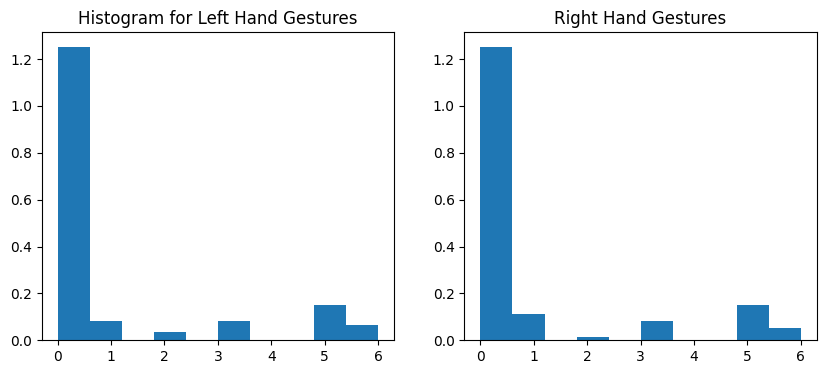

In [49]:
# Left and right hand gestures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(df['lhg'], density=True)
ax1.set_title("Histogram for Left Hand Gestures")
ax2.hist(df['rhg'], density=True)
ax2.set_title("Right Hand Gestures")
plt.show()

**Face Blendshape**

Using mediapipe [Hand Face Landmark Recognition Model](https://ai.google.dev/edge/mediapipe/solutions/vision/face_landmarker). I managed to detect the face gestures or none that I was making.

Here I commited a rookie mistake, I dismissed every facial expression with less accuracy than 50% to avoid noise, and it make sense but I should have left the data processing to this part. But what can I say I'm still a rookie and just getting my hands on this kind of work

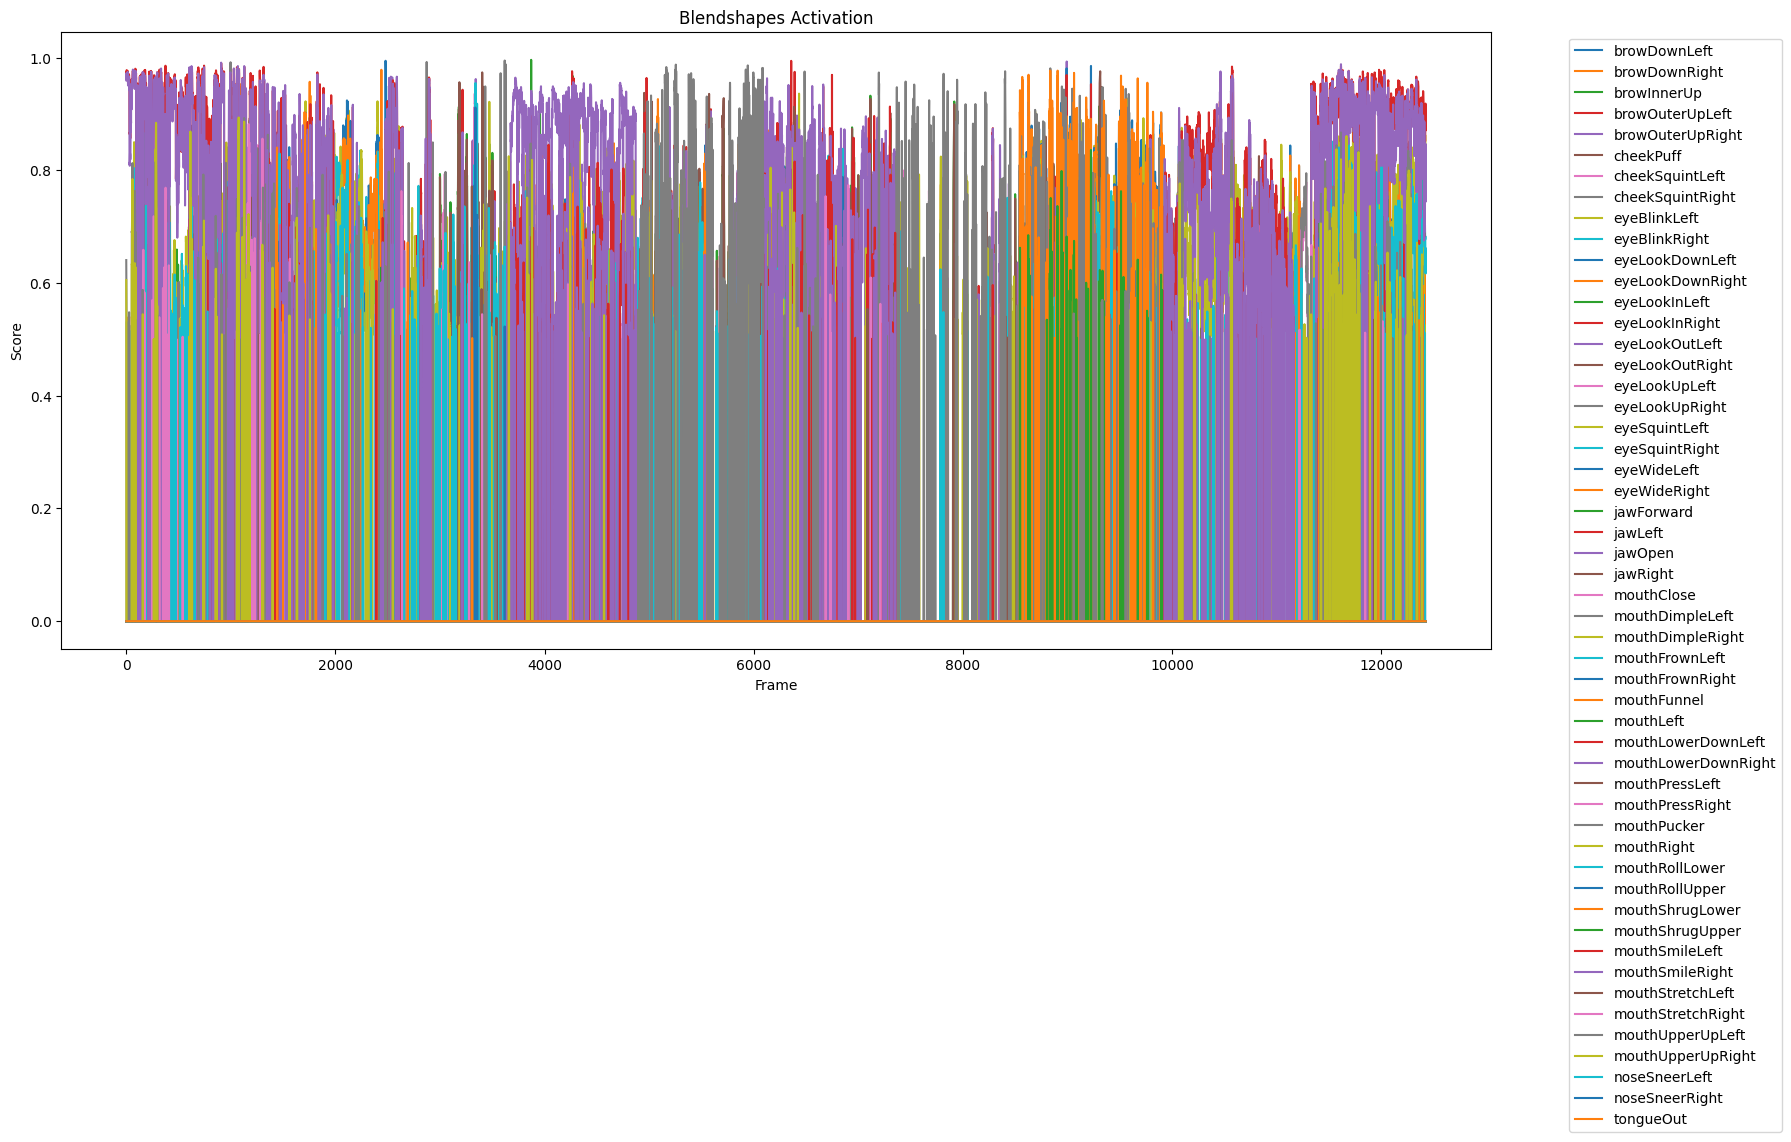

In [50]:
# Face Blendshape
plt.figure(figsize=(18, 10))

for c, column in enumerate(df.columns):
    if c < 2 or c > 53:
        continue
    else:
        plt.plot(df[column], label=column)

plt.title("Blendshapes Activation")
plt.xlabel("Frame")
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Random Forest Landmark
This data is pretty mucho processed, but after my card fraud detection I learned that no every feature is usefull, so as my first landmark I will use the Random Forest ML algorithm to test the best K features, building a pipeline


--- Using 5 Features ----
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96       387
         1.0       0.62      0.63      0.63       369
         2.0       0.48      0.50      0.49       332
         3.0       0.79      0.76      0.77       384
         4.0       0.70      0.70      0.70       406
         5.0       0.96      0.98      0.97       368
         6.0       0.59      0.54      0.56       365
         7.0       0.83      0.85      0.84       394
         8.0       0.92      0.94      0.93       404
         9.0       0.95      0.95      0.95       319

    accuracy                           0.78      3728
   macro avg       0.78      0.78      0.78      3728
weighted avg       0.78      0.78      0.78      3728

ROC-AUC: 0.9584681148955164


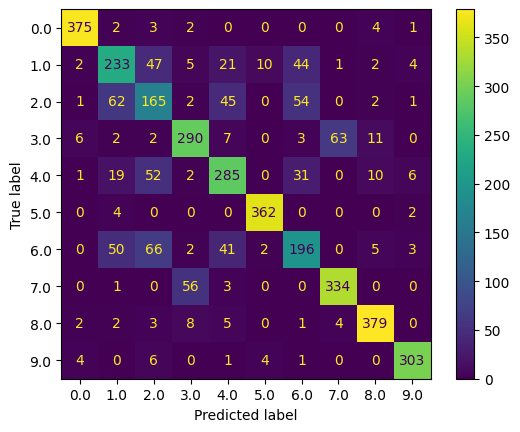

The best score achieved was:  0.9584681148955164  with k = 5

--- Using 10 Features ----
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       387
         1.0       0.92      0.92      0.92       369
         2.0       0.89      0.85      0.87       332
         3.0       0.96      0.93      0.95       384
         4.0       0.88      0.93      0.90       406
         5.0       0.99      1.00      0.99       368
         6.0       0.94      0.92      0.93       365
         7.0       0.97      0.98      0.97       394
         8.0       0.95      0.96      0.95       404
         9.0       0.98      0.98      0.98       319

    accuracy                           0.94      3728
   macro avg       0.94      0.94      0.94      3728
weighted avg       0.94      0.94      0.94      3728

ROC-AUC: 0.9953763081342911


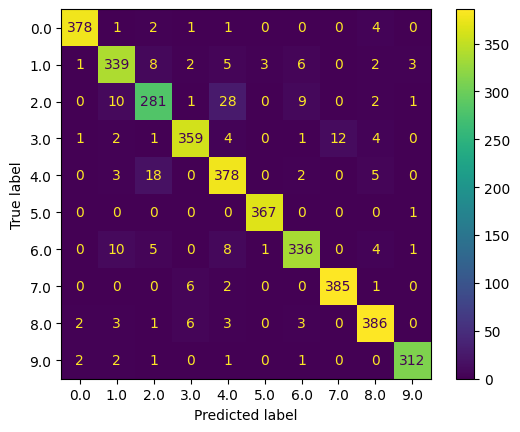

The best score achieved was:  0.9953763081342911  with k = 10

--- Using 15 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98       387
         1.0       0.91      0.92      0.92       369
         2.0       0.90      0.86      0.88       332
         3.0       0.99      0.98      0.98       384
         4.0       0.89      0.94      0.91       406
         5.0       0.99      1.00      0.99       368
         6.0       0.94      0.92      0.93       365
         7.0       0.99      0.98      0.99       394
         8.0       0.95      0.98      0.96       404
         9.0       0.99      0.98      0.99       319

    accuracy                           0.95      3728
   macro avg       0.95      0.95      0.95      3728
weighted avg       0.95      0.95      0.95      3728

ROC-AUC: 0.9967991568962156


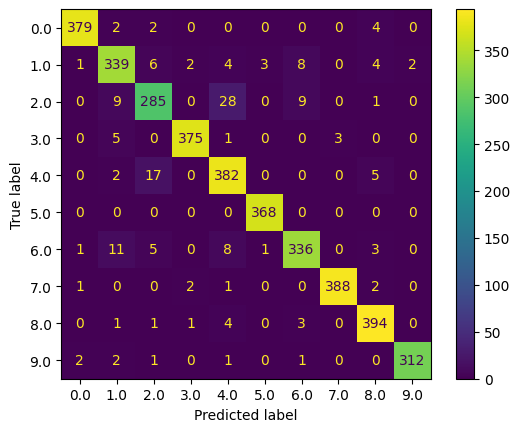

The best score achieved was:  0.9967991568962156  with k = 15

--- Using 20 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99       387
         1.0       0.97      0.97      0.97       369
         2.0       0.96      0.96      0.96       332
         3.0       0.99      0.99      0.99       384
         4.0       0.96      0.98      0.97       406
         5.0       0.99      1.00      0.99       368
         6.0       0.99      0.98      0.99       365
         7.0       1.00      0.99      0.99       394
         8.0       0.98      0.99      0.98       404
         9.0       0.99      0.99      0.99       319

    accuracy                           0.98      3728
   macro avg       0.98      0.98      0.98      3728
weighted avg       0.98      0.98      0.98      3728

ROC-AUC: 0.9994485782889271


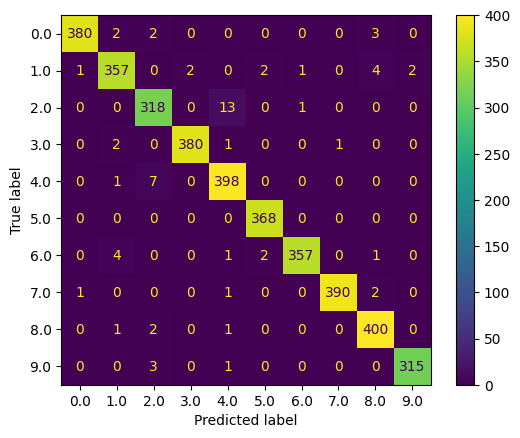

The best score achieved was:  0.9994485782889271  with k = 20

--- Using 25 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99       387
         1.0       0.98      0.97      0.98       369
         2.0       0.96      0.96      0.96       332
         3.0       0.99      0.99      0.99       384
         4.0       0.96      0.99      0.97       406
         5.0       0.99      1.00      0.99       368
         6.0       0.99      0.98      0.98       365
         7.0       1.00      0.99      0.99       394
         8.0       0.98      0.99      0.98       404
         9.0       0.99      0.98      0.99       319

    accuracy                           0.98      3728
   macro avg       0.98      0.98      0.98      3728
weighted avg       0.98      0.98      0.98      3728

ROC-AUC: 0.9997205854000001


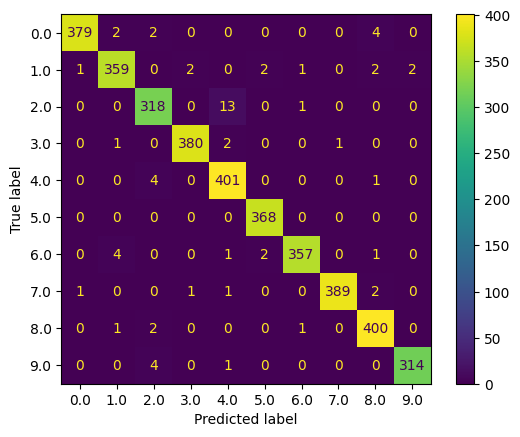

The best score achieved was:  0.9997205854000001  with k = 25

--- Using 30 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99       387
         1.0       0.98      0.97      0.98       369
         2.0       0.97      0.98      0.98       332
         3.0       0.99      0.99      0.99       384
         4.0       0.97      0.99      0.98       406
         5.0       0.99      1.00      0.99       368
         6.0       0.99      0.98      0.99       365
         7.0       1.00      0.99      0.99       394
         8.0       0.98      0.99      0.98       404
         9.0       0.99      0.98      0.99       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9996583067444501


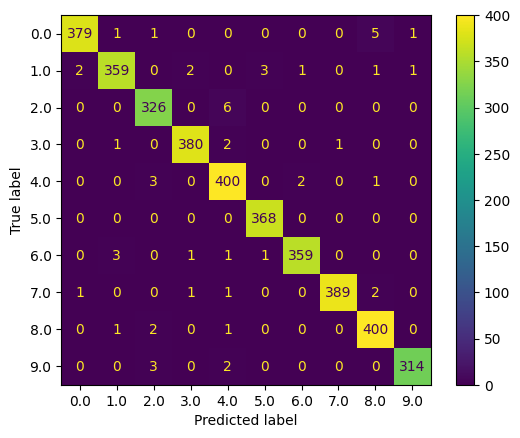

The best score achieved was:  0.9997205854000001  with k = 25

--- Using 35 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99       387
         1.0       0.99      0.98      0.98       369
         2.0       0.98      0.99      0.98       332
         3.0       0.99      0.99      0.99       384
         4.0       0.99      0.99      0.99       406
         5.0       0.99      1.00      0.99       368
         6.0       0.99      0.99      0.99       365
         7.0       0.99      0.99      0.99       394
         8.0       0.98      0.99      0.99       404
         9.0       1.00      0.99      0.99       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9998410755012935


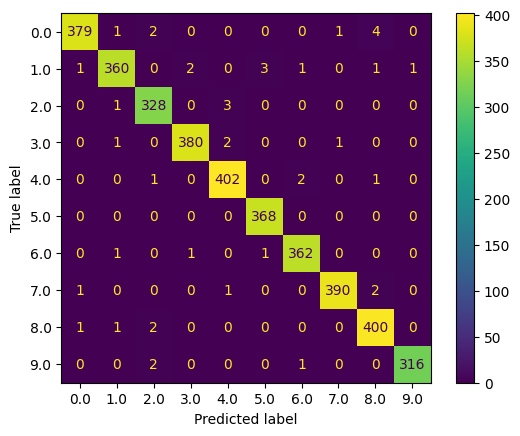

The best score achieved was:  0.9998410755012935  with k = 35

--- Using 40 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       387
         1.0       0.99      0.97      0.98       369
         2.0       0.98      0.98      0.98       332
         3.0       0.99      0.99      0.99       384
         4.0       0.98      0.99      0.99       406
         5.0       0.99      1.00      0.99       368
         6.0       0.98      1.00      0.99       365
         7.0       1.00      0.99      0.99       394
         8.0       0.99      1.00      0.99       404
         9.0       1.00      0.99      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9997600894969496


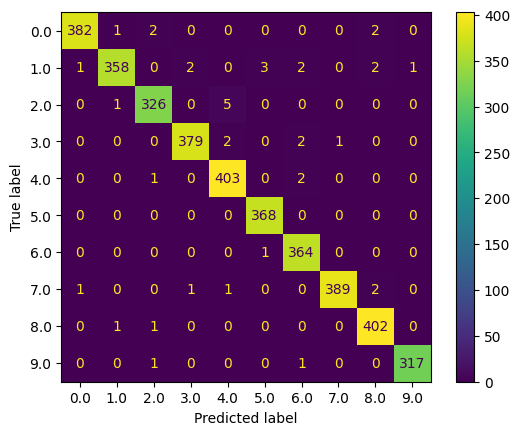

The best score achieved was:  0.9998410755012935  with k = 35

--- Using 45 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       387
         1.0       0.99      0.98      0.98       369
         2.0       0.99      0.99      0.99       332
         3.0       0.99      0.99      0.99       384
         4.0       0.99      0.99      0.99       406
         5.0       0.99      1.00      0.99       368
         6.0       0.98      0.99      0.99       365
         7.0       1.00      0.99      0.99       394
         8.0       0.99      1.00      0.99       404
         9.0       1.00      1.00      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9999009671715319


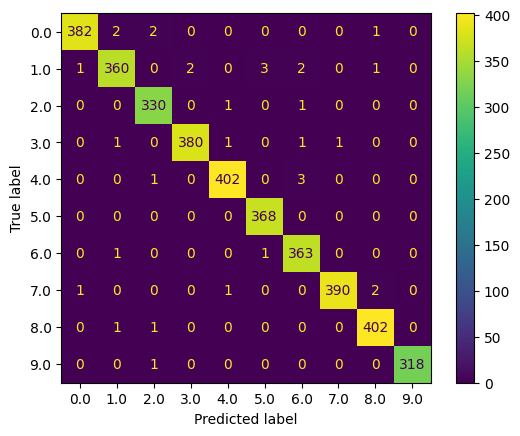

The best score achieved was:  0.9999009671715319  with k = 45

--- Using 50 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99       387
         1.0       0.98      0.98      0.98       369
         2.0       0.99      0.99      0.99       332
         3.0       0.99      0.99      0.99       384
         4.0       1.00      0.99      0.99       406
         5.0       0.99      1.00      0.99       368
         6.0       0.98      0.99      0.99       365
         7.0       1.00      0.99      0.99       394
         8.0       0.99      1.00      0.99       404
         9.0       1.00      1.00      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9999090749643861


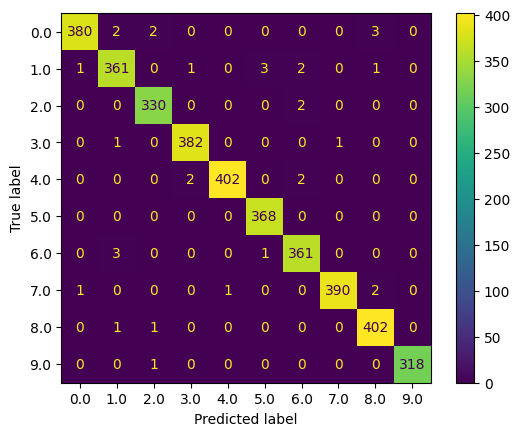

The best score achieved was:  0.9999090749643861  with k = 50

--- Using 55 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99       387
         1.0       0.99      0.98      0.99       369
         2.0       0.99      0.99      0.99       332
         3.0       0.99      1.00      0.99       384
         4.0       1.00      0.98      0.99       406
         5.0       0.99      1.00      1.00       368
         6.0       0.98      1.00      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      0.99      0.99       404
         9.0       1.00      0.99      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9997852143157331


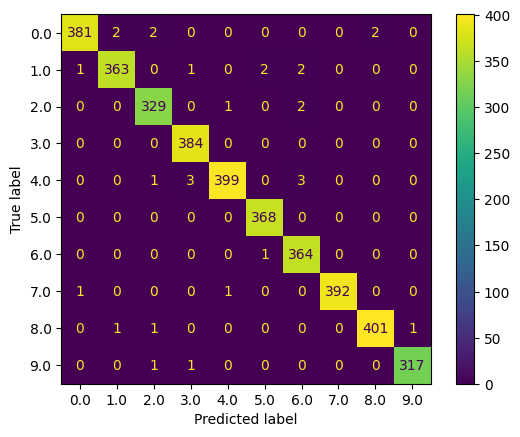

The best score achieved was:  0.9999090749643861  with k = 50

--- Using 60 Features ----
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       387
         1.0       0.99      0.98      0.99       369
         2.0       0.99      1.00      0.99       332
         3.0       0.99      1.00      1.00       384
         4.0       1.00      0.99      0.99       406
         5.0       0.99      1.00      0.99       368
         6.0       0.99      0.99      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      0.99      0.99       404
         9.0       1.00      1.00      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9999259193756102


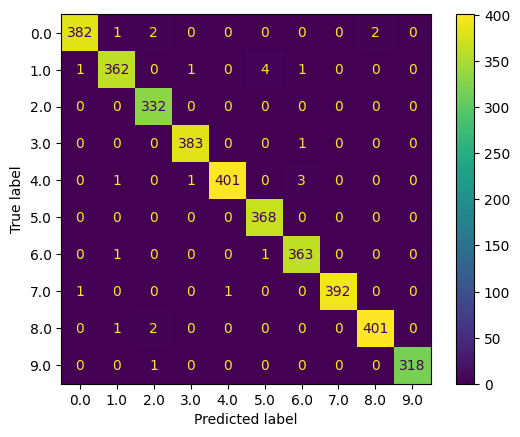

The best score achieved was:  0.9999259193756102  with k = 60

--- Using 65 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99       387
         1.0       0.99      0.99      0.99       369
         2.0       0.99      1.00      0.99       332
         3.0       0.99      1.00      0.99       384
         4.0       1.00      0.99      0.99       406
         5.0       0.99      1.00      1.00       368
         6.0       0.99      0.99      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      0.99      0.99       404
         9.0       1.00      0.99      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9999482956267214


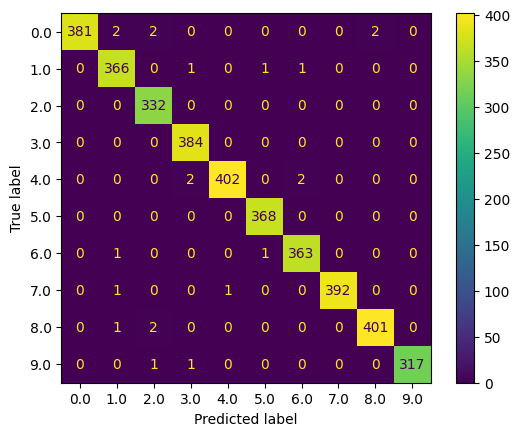

The best score achieved was:  0.9999482956267214  with k = 65

--- Using 70 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       387
         1.0       0.99      0.99      0.99       369
         2.0       0.99      1.00      0.99       332
         3.0       1.00      1.00      1.00       384
         4.0       1.00      0.99      0.99       406
         5.0       0.99      1.00      1.00       368
         6.0       0.98      0.99      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      0.99      1.00       404
         9.0       1.00      0.99      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9999599959921479


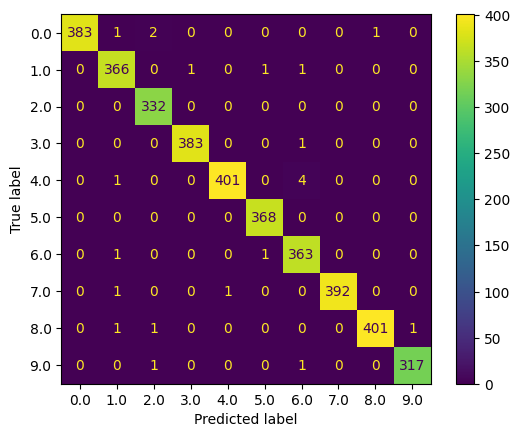

The best score achieved was:  0.9999599959921479  with k = 70

--- Using 75 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       387
         1.0       0.98      0.99      0.99       369
         2.0       0.99      1.00      0.99       332
         3.0       0.99      1.00      1.00       384
         4.0       1.00      0.99      0.99       406
         5.0       0.99      1.00      1.00       368
         6.0       0.98      0.99      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      1.00      1.00       404
         9.0       1.00      0.99      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9999509545689105


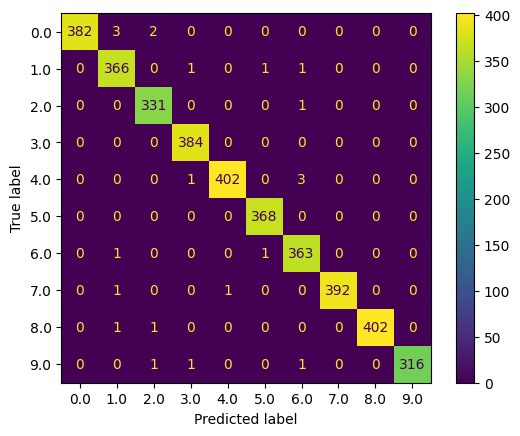

The best score achieved was:  0.9999599959921479  with k = 70

--- Using 80 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       387
         1.0       0.99      0.99      0.99       369
         2.0       0.99      1.00      0.99       332
         3.0       0.99      1.00      1.00       384
         4.0       1.00      0.99      0.99       406
         5.0       0.99      1.00      1.00       368
         6.0       0.99      1.00      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      0.99      0.99       404
         9.0       1.00      0.99      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9999497524614027


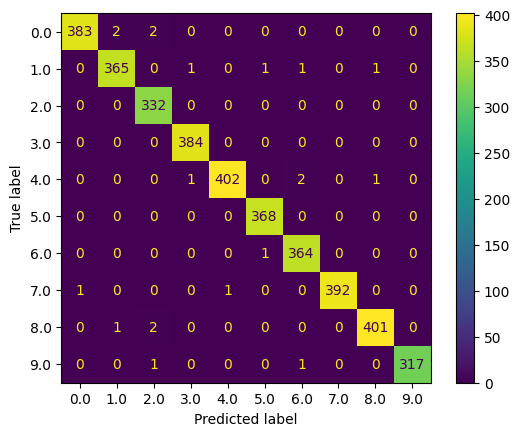

The best score achieved was:  0.9999599959921479  with k = 70

--- Using 85 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       387
         1.0       0.99      0.99      0.99       369
         2.0       0.99      1.00      0.99       332
         3.0       0.99      1.00      1.00       384
         4.0       1.00      0.99      0.99       406
         5.0       0.99      1.00      1.00       368
         6.0       0.99      1.00      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      1.00      1.00       404
         9.0       1.00      1.00      1.00       319

    accuracy                           1.00      3728
   macro avg       1.00      1.00      1.00      3728
weighted avg       1.00      1.00      1.00      3728

ROC-AUC: 0.9999526753581147


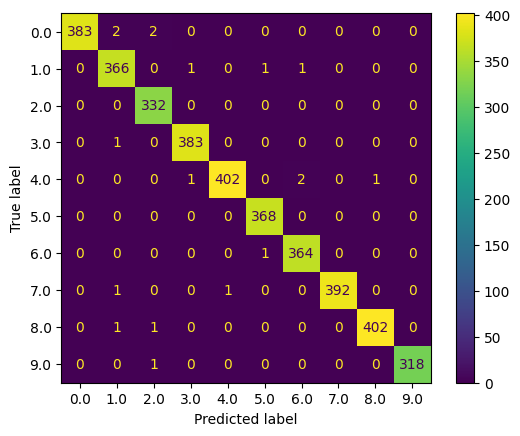

The best score achieved was:  0.9999599959921479  with k = 70

--- Using 90 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       387
         1.0       0.98      0.99      0.99       369
         2.0       0.99      0.99      0.99       332
         3.0       0.99      1.00      1.00       384
         4.0       1.00      0.99      0.99       406
         5.0       0.99      1.00      1.00       368
         6.0       0.98      0.99      0.98       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      0.99      1.00       404
         9.0       1.00      0.99      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9999613186523403


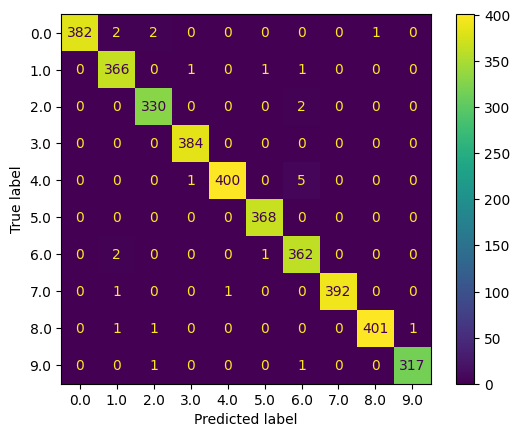

The best score achieved was:  0.9999613186523403  with k = 90

--- Using 95 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       387
         1.0       0.99      0.99      0.99       369
         2.0       0.99      1.00      0.99       332
         3.0       1.00      1.00      1.00       384
         4.0       1.00      0.99      1.00       406
         5.0       0.99      1.00      1.00       368
         6.0       0.99      0.99      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      0.99      1.00       404
         9.0       1.00      1.00      1.00       319

    accuracy                           1.00      3728
   macro avg       1.00      1.00      1.00      3728
weighted avg       1.00      1.00      1.00      3728

ROC-AUC: 0.9998123973503225


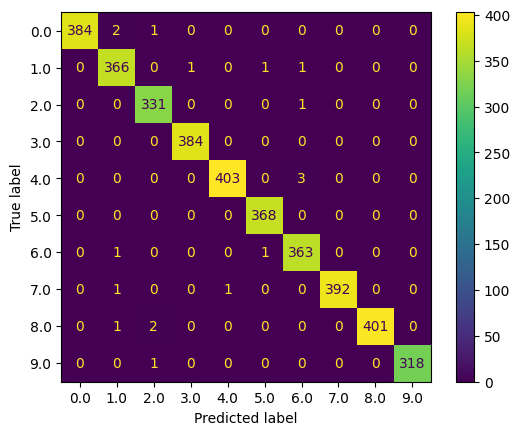

The best score achieved was:  0.9999613186523403  with k = 90

--- Using 100 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       387
         1.0       0.99      0.99      0.99       369
         2.0       0.99      1.00      0.99       332
         3.0       1.00      1.00      1.00       384
         4.0       1.00      0.99      0.99       406
         5.0       0.99      1.00      1.00       368
         6.0       0.98      0.99      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      1.00      1.00       404
         9.0       1.00      1.00      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9999259938471919


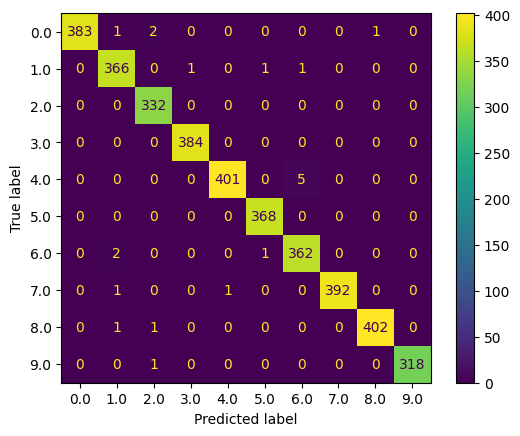

The best score achieved was:  0.9999613186523403  with k = 90

--- Using 105 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       387
         1.0       0.99      0.99      0.99       369
         2.0       0.99      1.00      1.00       332
         3.0       0.99      1.00      1.00       384
         4.0       1.00      0.99      1.00       406
         5.0       0.99      1.00      1.00       368
         6.0       0.99      1.00      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      1.00      1.00       404
         9.0       1.00      1.00      1.00       319

    accuracy                           1.00      3728
   macro avg       1.00      1.00      1.00      3728
weighted avg       1.00      1.00      1.00      3728

ROC-AUC: 0.999961907091228


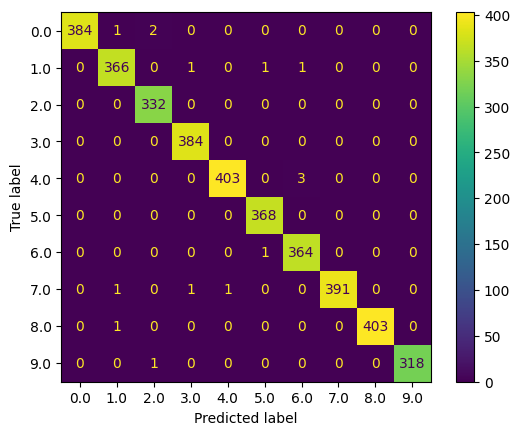

The best score achieved was:  0.999961907091228  with k = 105

--- Using 110 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       387
         1.0       0.99      0.99      0.99       369
         2.0       0.99      1.00      0.99       332
         3.0       1.00      1.00      1.00       384
         4.0       1.00      0.99      1.00       406
         5.0       0.99      1.00      1.00       368
         6.0       0.99      1.00      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      0.99      1.00       404
         9.0       1.00      0.99      1.00       319

    accuracy                           1.00      3728
   macro avg       1.00      1.00      1.00      3728
weighted avg       1.00      1.00      1.00      3728

ROC-AUC: 0.9999554685964324


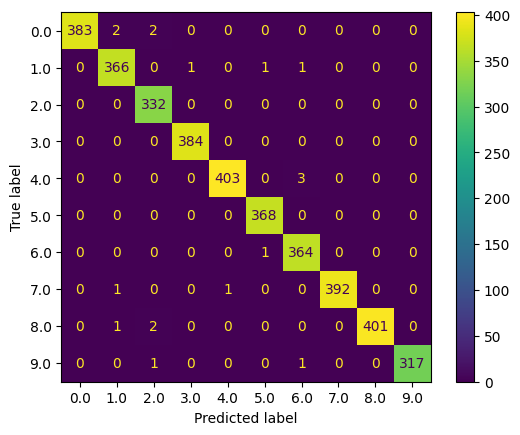

The best score achieved was:  0.999961907091228  with k = 105

--- Using 115 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       387
         1.0       0.99      0.99      0.99       369
         2.0       0.99      1.00      0.99       332
         3.0       0.99      1.00      1.00       384
         4.0       1.00      0.99      1.00       406
         5.0       0.99      1.00      1.00       368
         6.0       0.99      1.00      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      0.99      1.00       404
         9.0       1.00      0.99      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      1.00      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9999622655716737


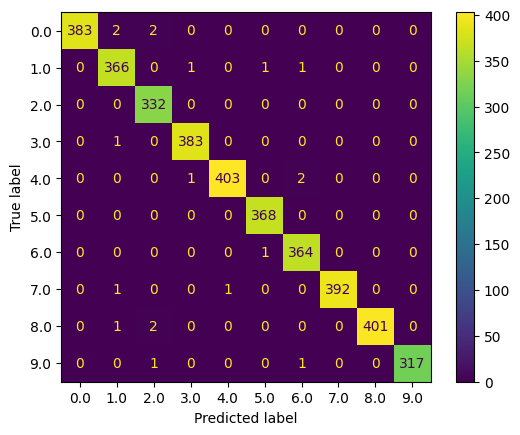

The best score achieved was:  0.9999622655716737  with k = 115

--- Using 120 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       387
         1.0       0.99      0.99      0.99       369
         2.0       0.99      1.00      0.99       332
         3.0       0.99      1.00      1.00       384
         4.0       1.00      0.99      1.00       406
         5.0       0.99      1.00      1.00       368
         6.0       0.98      0.99      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      1.00      1.00       404
         9.0       1.00      0.99      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9999448337890839


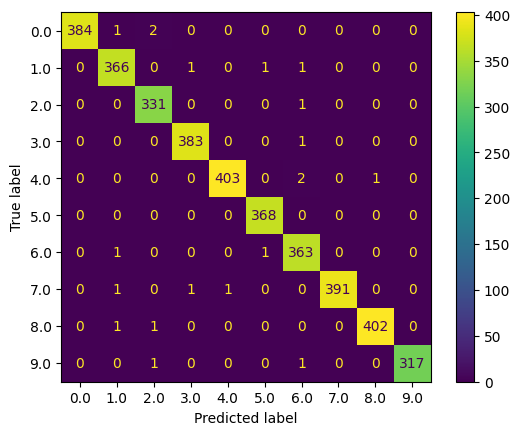

The best score achieved was:  0.9999622655716737  with k = 115

--- Using 125 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       387
         1.0       0.99      0.99      0.99       369
         2.0       0.99      1.00      0.99       332
         3.0       0.99      1.00      1.00       384
         4.0       1.00      0.99      0.99       406
         5.0       0.99      1.00      1.00       368
         6.0       0.98      1.00      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      1.00      1.00       404
         9.0       1.00      0.99      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9999480650724012


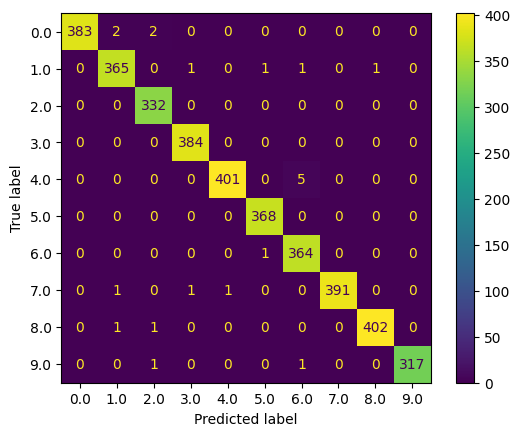

The best score achieved was:  0.9999622655716737  with k = 115


/Users/diegopez/Library/Python/3.9/lib/python/site-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=130 is greater than n_features=125. All the features will be returned.
  warnings.warn(



--- Using 130 Features ----
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       387
         1.0       0.99      0.99      0.99       369
         2.0       0.99      1.00      0.99       332
         3.0       0.99      1.00      1.00       384
         4.0       1.00      0.99      1.00       406
         5.0       0.99      1.00      1.00       368
         6.0       0.99      1.00      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      0.99      1.00       404
         9.0       1.00      0.99      1.00       319

    accuracy                           1.00      3728
   macro avg       1.00      1.00      1.00      3728
weighted avg       1.00      1.00      1.00      3728

ROC-AUC: 0.9999331736684025


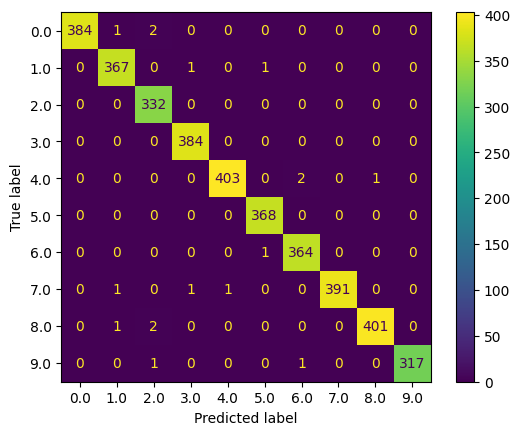

The best score achieved was:  0.9999622655716737  with k = 115


In [51]:
# Sklearn Imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Test Train Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

best_k = 0
best_score = 0
for i in range(5, X_train.shape[1], 5):
    pipeline = Pipeline([
        ('variance', VarianceThreshold(threshold=0.0)),
        ('selector', SelectKBest(f_classif, k=i)),
        ('random_forest', RandomForestClassifier())
    ])

    pipeline.fit(X_train, y_train)
    prediction = pipeline.predict(X_test)
    probability = pipeline.predict_proba(X_test)

    print(f"\n--- Using {i} Features ----")
    print(classification_report(y_test, prediction))

    roc_auc = roc_auc_score(y_test, probability, multi_class='ovr')
    print("ROC-AUC:",
          roc_auc)

    if best_score < roc_auc:
        best_score = roc_auc
        best_k = i

    cm = confusion_matrix(
        y_test,
        prediction,
        labels=pipeline.named_steps['random_forest'].classes_
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=pipeline.named_steps['random_forest'].classes_
    )

    disp.plot()
    plt.show()

    print("The best score achieved was: ", best_score, " with k =", best_k)

I think I got it, actually with 5 misserable features this model was really accurate, I mean it makes sense since the gestures features are broken and make most of the work, but the model becoming a 99.99% accurate with more extra features was absoulte cinema

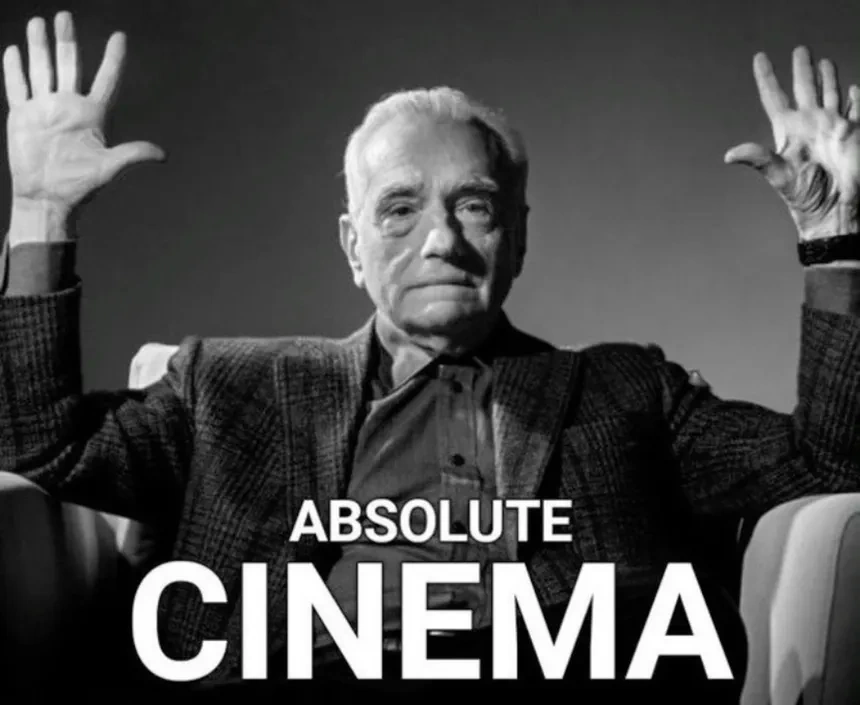

This as a initial Landmark seems to be actually finished work but I will try to level up my game trying to use XGBoost to make a better model using the 120 significant features and actually most of the features were important!

### XGBoost
Just doing it because I can, and I want, I wont even train a data set significant enough for this to be useful or maybe I will

In [52]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'selector__k': [120],
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.05, 0.1, 0.2],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

xgb_pipeline = Pipeline([
    ('variance', VarianceThreshold(threshold=0.0)),
    ('selector', SelectKBest(f_classif)),
    ('xgb', XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42
    ))
])

grid = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('variance', VarianceThreshold()),
                                       ('selector', SelectKBest()),
                                       ('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='mlogloss',
                                                      feature_types=None,
                                                      gamma=No...
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None,
                                                      objective='multi:softprob', ...))]),
             n_jobs=-1,
             param_grid={'selector__k': [120],
                         'xgb__colsample_bytree': [0.8, 1.0],
                         'xgb__learning_rate': [0.05, 0.1, 0.2],
                         'xgb__max_depth': [3, 4, 5],
                         'xgb__n_estimators': [100, 200],
                         'xgb__subsample': [0.8, 1.0]},
             scoring='accuracy')

Best Params: {'selector__k': 120, 'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__subsample': 0.8}
Best Score: 0.9934452223397437
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       387
         1.0       0.98      0.99      0.99       369
         2.0       0.99      0.99      0.99       332
         3.0       0.99      1.00      0.99       384
         4.0       1.00      0.99      0.99       406
         5.0       0.99      1.00      1.00       368
         6.0       0.99      1.00      0.99       365
         7.0       1.00      0.99      1.00       394
         8.0       1.00      1.00      1.00       404
         9.0       0.99      1.00      1.00       319

    accuracy                           0.99      3728
   macro avg       0.99      0.99      0.99      3728
weighted avg       0.99      0.99      0.99      3728

ROC-AUC: 0.9999507237901428


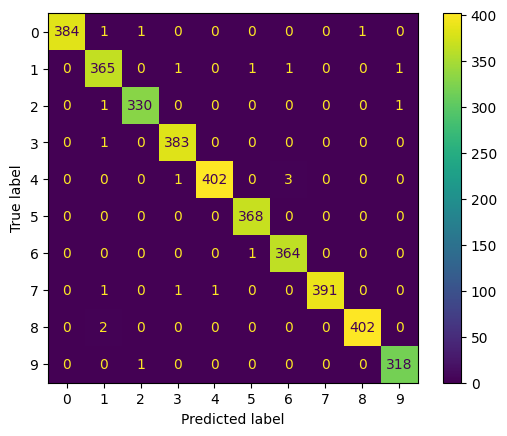

In [53]:
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

grid_prediction = grid.predict(X_test)
grid_probability = grid.predict_proba(X_test)

print(classification_report(y_test, grid_prediction))

grid_roc_auc = roc_auc_score(y_test, grid_probability, multi_class='ovr')
print("ROC-AUC:", grid_roc_auc)

cm = confusion_matrix(
    y_test,
    grid_prediction,
    labels=grid.best_estimator_.named_steps['xgb'].classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=grid.best_estimator_.named_steps['xgb'].classes_
)

disp.plot()
plt.show()


All this problem just to go from 99.9960% to 99.9961% ROC-AUC
Just to flex in my resume I will use XGBoost model, but there is no significant difference

### Export Final Pipeline

In [54]:
import joblib
feature_names = X.columns.tolist()
joblib.dump((grid, feature_names), "emote_detection_pipeline_v2.pkl")

['emote_detection_pipeline_v2.pkl']